# Uinta ca. 754 Ma paleomagnetic pole

## Geologic Context

- Terrane: Laurentia.
- Compiled unit/pole label: Uinta Mountain Group.

## Paleomagnetic And Rock Magnetic Data

- B = 9 sites, N = 80 samples; mean direction DEC/INC = 270.2°/2.0°; K = 61.5; A95 = 4.7°.
- Rock-magnetic interpretation: expand with mineral carriers/coercivity/unblocking evidence from source studies.

## Age Constraints

- Current bracket: lomagage 742.0 Ma, himagage 766.0 Ma.
- Compilation method note: maximum depositional age constraints from detrital zircon U-Pb data from Dehler et al., 2010 is 766±5 Ma. Using Chuar group DZ data constrains the younger bound

## References

- Paleomagnetic source: Weil, A.B., Geissman, J.W., Ashby, J.M. (2006). A new paleomagnetic pole for the Neoproterozoic Uinta Mountain supergroup, Central Rocky Mountain States, USA. Precambrian Res., 147, 234-259.
- Geochronology / age-constraint note (compilation): maximum depositional age constraints from detrital zircon U-Pb data from Dehler et al., 2010 is 766±5 Ma. Using Chuar group DZ data constrains the younger bound

In [1]:
import sys
sys.path.append('../data/')
from pole_tools import *

Laurentia_poles = get_Laurentia_poles() # get all poles
Laurentia_stricto_poles = get_Laurentia_stricto_poles() # get only Laurentia poles

%config InlineBackend.figure_format='retina'
%matplotlib inline

In [2]:
R2_test('Uinta Mountain Group',Laurentia_poles)

N = 80 (N ≥ 25; sufficient sample number);
B = 9 (B ≥ 8; sufficient site number);
K = 62 (70 ≥ K ≥ 10; meets PSV criteria);
A_95 of 4.7 is too small for Deenen criteria of 5.0 for this number of sites


In [ ]:
Uinta_sites_geo, Uinta_sites_tc = load_magic_sites('../data/754_Uinta/sites.txt')
Uinta_geo = Uinta_sites_geo.rename(columns={'dir_dec': 'dec_is', 'dir_inc': 'inc_is', 'dir_k': 'k', 'dir_alpha95': 'alpha95', 'dir_n_samples': 'n/no'})
Uinta_tc = Uinta_sites_tc.rename(columns={'dir_dec': 'dec_tc', 'dir_inc': 'inc_tc'})
Uinta_data = Uinta_geo[['site', 'strike', 'dip', 'n/no', 'dec_is', 'inc_is', 'alpha95', 'k', 'section', 'filtered_out_by_direction']].merge(Uinta_tc[['site', 'dec_tc', 'inc_tc']], on='site', how='left').reset_index(drop=True)
Uinta_data.head()

,site,strike,dip,n/no,dec_is,inc_is,alpha95,k,dec_tc,inc_tc,section,filtered_out_by_direction
0,SC 2a,325,81,5/11,104.5,36.0,11.5,45.00,97.9,-25.3,Sheep Creek Canyon,yes
1,SC 5a,324,80,4/12,102.6,58.7,12.7,53.00,77.4,-11.0,Sheep Creek Canyon,yes
2,SC 6a,325,78,7/12,114.0,31.3,12.6,23.80,105.7,-18.8,Sheep Creek Canyon,yes
3,SC 9b,293,43,3/20,97.5,-8.2,17.1,52.90,107.2,-16.5,Sheep Creek Canyon,NaN
4,SC 10a,301,55,3/3,81.2,33.3,11.9,108.40,71.3,-7.1,Sheep Creek Canyon,yes


In [4]:
Uinta_data_filtered = Uinta_data[Uinta_data['filtered_out_by_direction'] != 'yes']
Uinta_data_filtered.head()

,site,strike,dip,n/no,dec_is,inc_is,alpha95,k,dec_tc,inc_tc,section,filtered_out_by_direction
3,SC 9b,293,43,3/20,97.5,-8.2,17.1,52.90,107.2,-16.5,Sheep Creek Canyon,NaN
5,SC 11,296,39,12/12,98.1,-12.5,4.1,115.00,110.0,-20.9,Sheep Creek Canyon,NaN
6,SC 12,297,36,12/14,95.3,6.5,5.3,69.20,95.5,-7.1,Sheep Creek Canyon,NaN
7,SC 13,286,38,2/7,88.7,15.6,6.5,1502.00,83.0,2.0,Sheep Creek Canyon,NaN
9,SC 14,301,39,4/15,105.3,6.4,3.4,718.10,104.7,-4.7,Sheep Creek Canyon,NaN


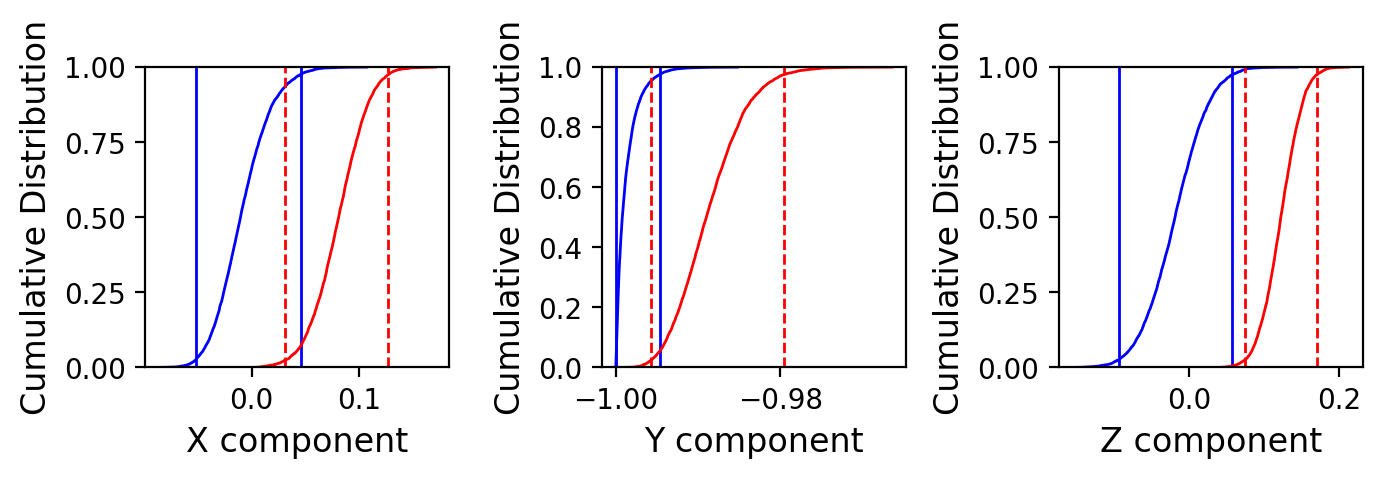

Fail, distinct in z


0

In [5]:
ipmag.reversal_test_bootstrap(Uinta_data_filtered['dec_tc'].tolist(),Uinta_data_filtered['inc_tc'].tolist())

In [6]:
ipmag.reversal_test_MM1990(Uinta_data_filtered['dec_tc'].tolist(),Uinta_data_filtered['inc_tc'].tolist())

Results of Watson V test: 

Watson's V:           14.2
Critical value of V:  6.0
"Fail": Since V is greater than Vcrit, the two means can
be distinguished at the 95% confidence level.

M&M1990 classification:

Angle between data set means: 9.7
Critical angle for M&M1990:   6.3



(0, 9.653840797722166, 6.287381934016658, '')

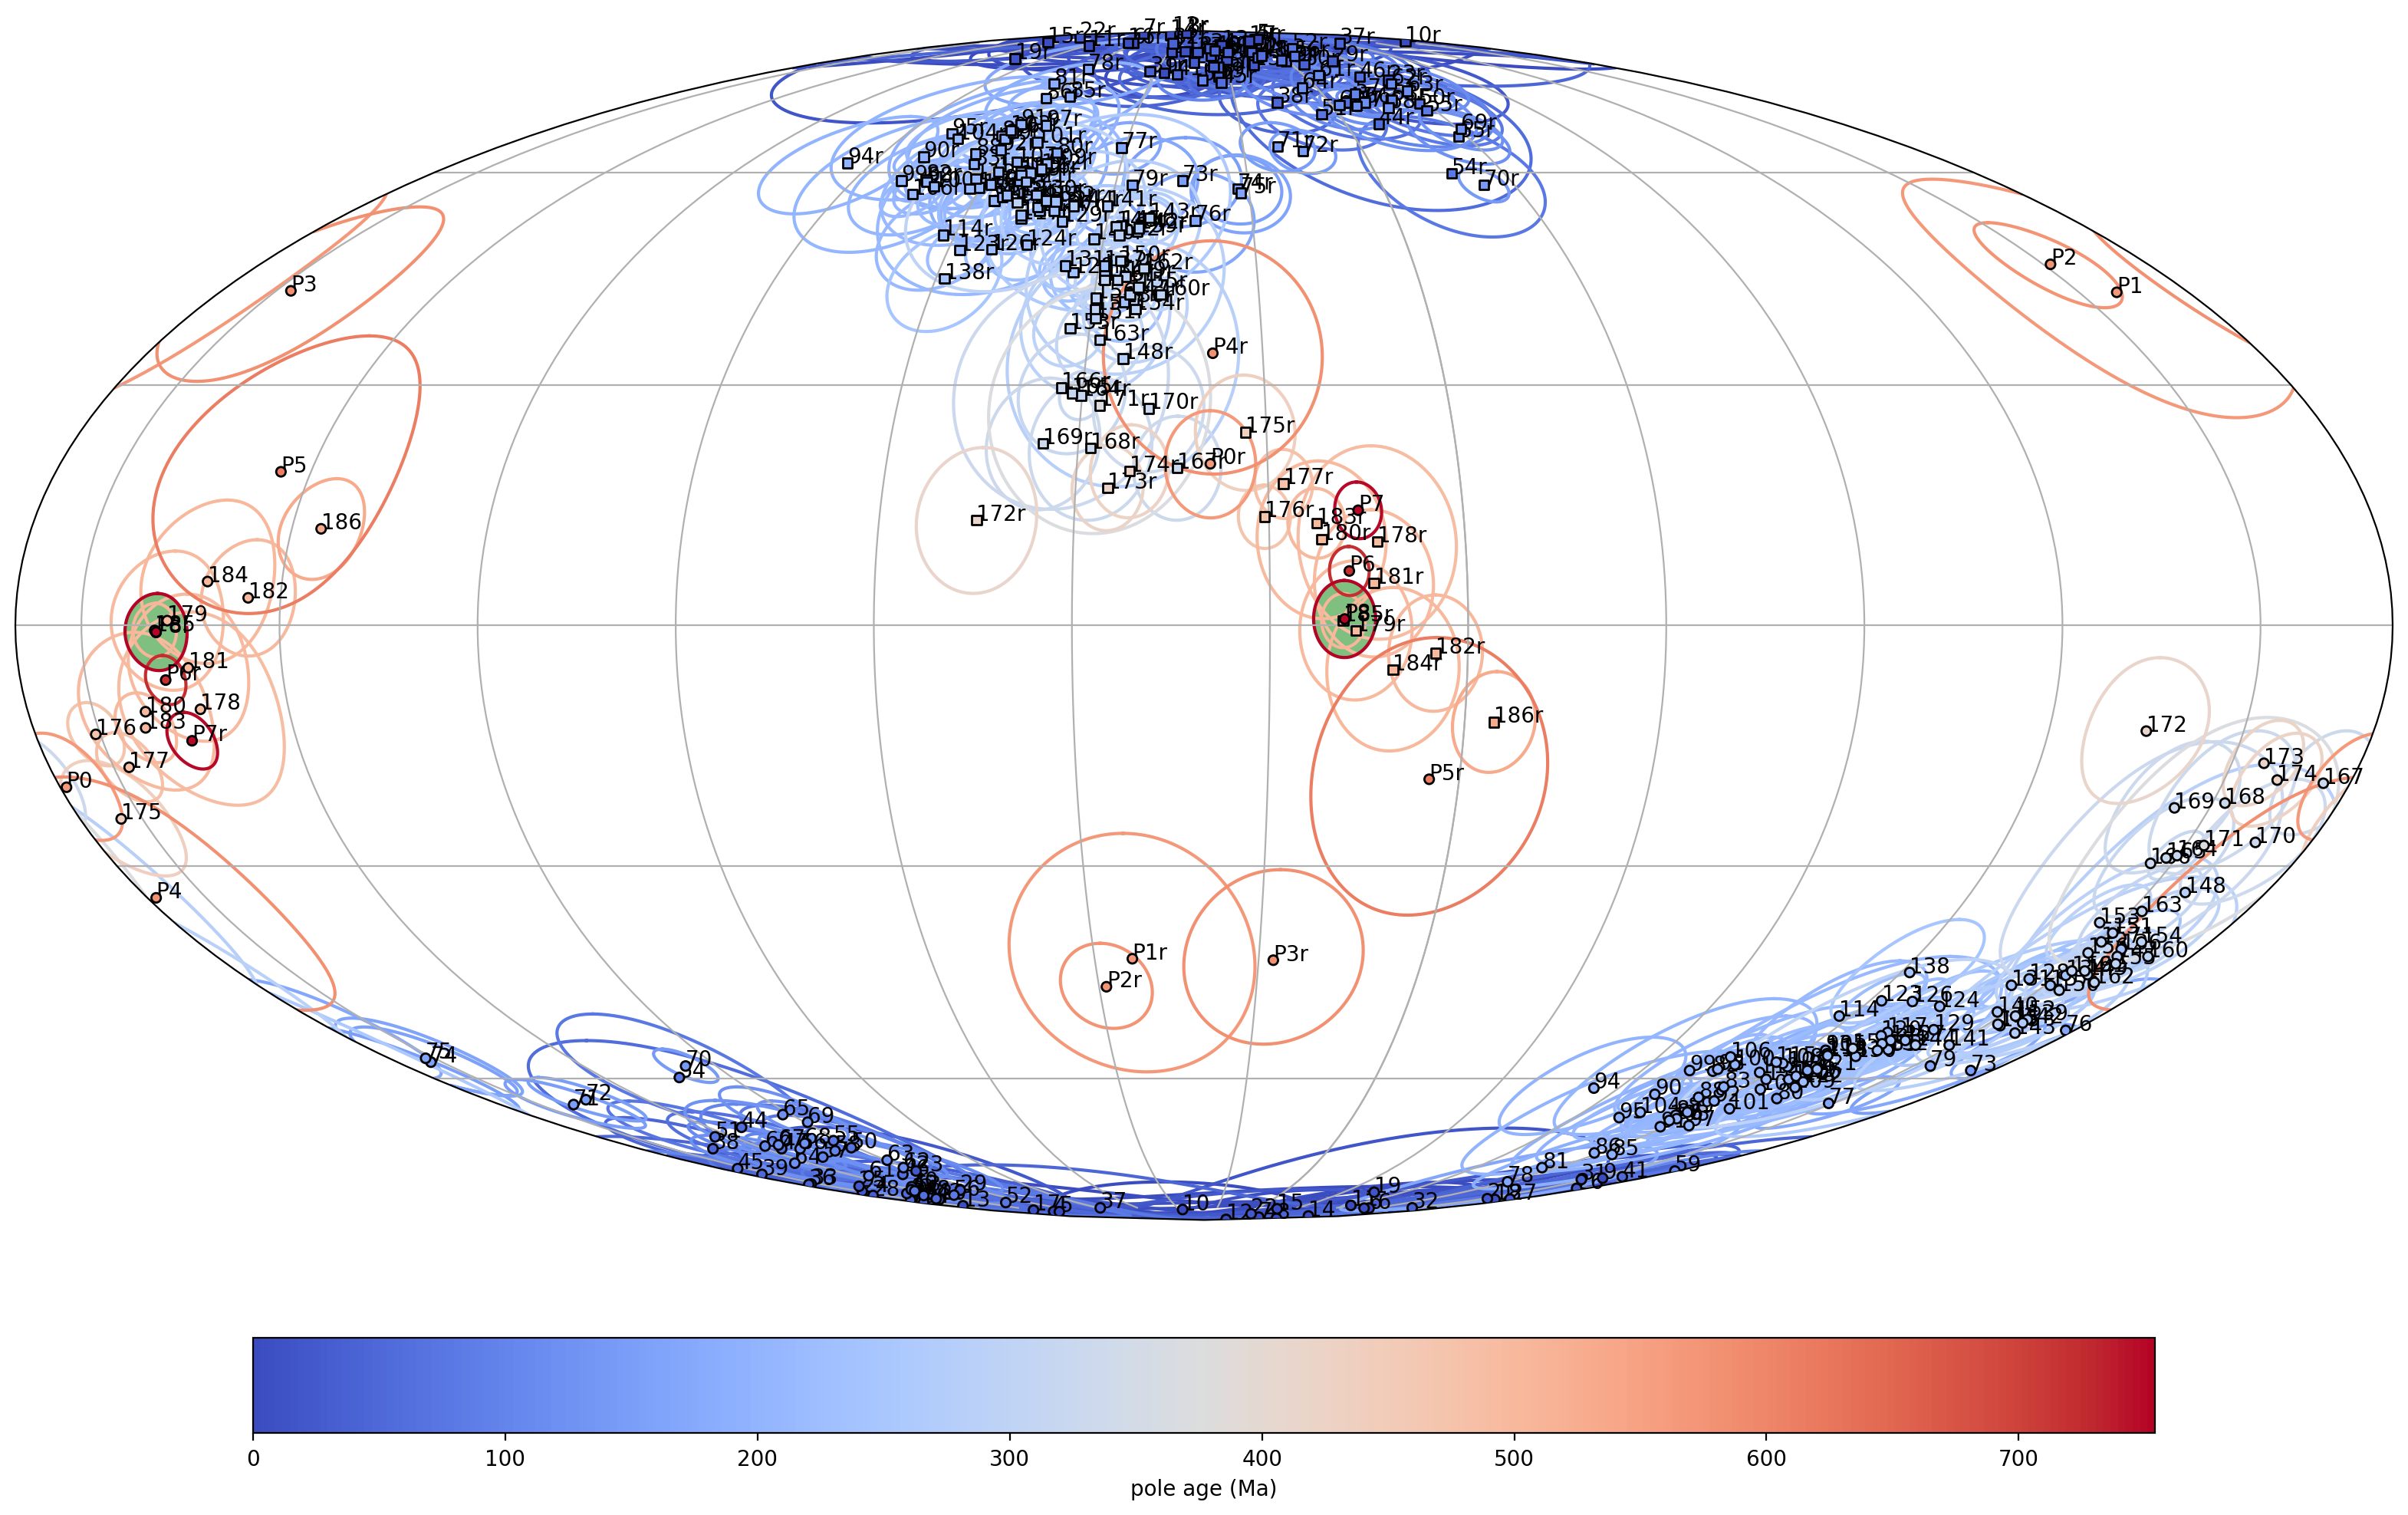

In [7]:
plot_pole_overlap('Uinta Mountain Group',Laurentia_stricto_poles,Torsvik2012_Laurentia)